In [79]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import re

In [80]:
# ========= 1. 實驗設定 (Configuration) =========

base_dir = r"C:\experiment\1D"

experiments = [
    {"file": os.path.join(base_dir, "t0103", "t0103.csv"), "color": "steelblue"   , "marker": "s", "group": "5cm"},
    {"file": os.path.join(base_dir, "t0104", "t0104.csv"), "color": "gray"        , "marker": "^", "group": "7cm"},
    {"file": os.path.join(base_dir, "t0105", "t0105.csv"), "color": "firebrick"   , "marker": "D", "group": "10cm"},
    {"file": os.path.join(base_dir, "t0106", "t0106.csv"), "color": "GoldEnrod"   , "marker": "d", "group": "12cm"},
    {"file": os.path.join(base_dir, "t0100", "t0100.csv"), "color": "ForestGreen" , "marker": "o", "group": "15cm"},
    # {"file": os.path.join(base_dir, "t0107", "t0107.csv"), "color": "purple"     , "marker": "v", "group": "150P"}
]

# 圖表 X 軸 (Normal Stress) 顯示範圍
xlim_min = 6
xlim_max = 34


In [81]:
# ========= 2. 資料處理 (Data Processing) =========

def extract_sigma(run_name):
    """ 從 run1_32MPa 這樣的字串中提取 32 作為數值 """
    match = re.search(r'_(\d+)MPa', str(run_name))
    if match:
        return float(match.group(1))
    return np.nan


def process_data(target_metric):
    """ 讀取 CSV 並計算各組在每個 sigma 下的 median 與 IQR """
    processed_data = []
    for exp in experiments:
        if not os.path.exists(exp['file']):
            print(f"找不到檔案: {exp['file']}")
            continue
            
        df = pd.read_csv(exp['file'])
        
        if 'skipped' in df.columns:
            df = df[df['skipped'] != 'YES'].copy()
            
        if target_metric == 'k' and 'k' in df.columns:
            df = df[pd.to_numeric(df['k'], errors='coerce') >= 0]
        
        if target_metric not in df.columns:
            continue
            
        # 提取 sigma
        df['sigma'] = df['Run'].apply(extract_sigma)
        df = df.dropna(subset=['sigma', target_metric])
        
        # 計算各個 sigma 的統計量
        stats = df.groupby('sigma')[target_metric].agg(
            median='median',
            q1=lambda x: x.quantile(0.25),
            q3=lambda x: x.quantile(0.75)
        ).reset_index()
        
        processed_data.append({
            'group': exp['group'],
            'color': exp['color'],
            'marker': exp['marker'],
            'stats': stats
        })
    return processed_data


def process_delta_data():
    """
    讀取 CSV，計算 delta：
    1. 每個事件取 delta_E2、delta_E3、delta_E4 的平均值
    2. 依 sigma 分組，計算中位數與 IQR
    """
    processed_data = []
    for exp in experiments:
        if not os.path.exists(exp['file']):
            print(f"找不到檔案: {exp['file']}")
            continue
            
        df = pd.read_csv(exp['file'])
        
        if 'skipped' in df.columns:
            df = df[df['skipped'] != 'YES'].copy()
            
        # 檢查必要欄位
        required_cols = ['delta_E2', 'delta_E3', 'delta_E4']
        if not all(c in df.columns for c in required_cols):
            continue
        
        # 轉數值
        for c in required_cols:
            df[c] = pd.to_numeric(df[c], errors='coerce')
        
        # 去除任一欄位為 NaN 的列
        df = df.dropna(subset=required_cols)
        
        # 計算每個事件的 delta 平均值 (E2+E3+E4)/3
        df['delta_avg'] = df[required_cols].mean(axis=1)
        
        # 提取 sigma
        df['sigma'] = df['Run'].apply(extract_sigma)
        df = df.dropna(subset=['sigma', 'delta_avg'])
        
        # 計算各個 sigma 的統計量
        stats = df.groupby('sigma')['delta_avg'].agg(
            median='median',
            q1=lambda x: x.quantile(0.25),
            q3=lambda x: x.quantile(0.75)
        ).reset_index()
        
        processed_data.append({
            'group': exp['group'],
            'color': exp['color'],
            'marker': exp['marker'],
            'stats': stats
        })
    return processed_data


In [82]:
# ========= 3. 繪製圖表函數 (Plotting Function) =========

def plot_metric(target_metric, title, ylabel, use_delta=False):
    """繪製以 sigma 為 X 軸的圖表，各實驗為不同系列。"""
    if use_delta:
        data_to_plot = process_delta_data()
    else:
        data_to_plot = process_data(target_metric)
    
    if not data_to_plot:
        print(f"找不到 {target_metric} 的資料")
        return
        
    fig, ax = plt.subplots(figsize=(10, 6))
    
    all_sigmas = []
    texts_to_draw = []
    for item in data_to_plot:
        stats = item['stats']
        sigmas = stats['sigma'].values
        medians = stats['median'].values
        yerr_lower = medians - stats['q1'].values
        yerr_upper = stats['q3'].values - medians
        
        all_sigmas.extend(sigmas)
        
        ax.errorbar(
            sigmas, medians, 
            yerr=[yerr_lower, yerr_upper], 
            fmt=item['marker'], color=item['color'], label=item['group'],
            markersize=10, capsize=5, 
            markerfacecolor='none', markeredgewidth=2,
            elinewidth=1.5, alpha=0.8, zorder=3
        )
        
        # Add trend line
        if len(sigmas) > 1:
            slope, intercept = np.polyfit(sigmas, medians, 1)
            x_line = np.array([sigmas.min(), sigmas.max()])
            y_line = slope * x_line + intercept
            ax.plot(x_line, y_line, color=item['color'], linestyle='--', linewidth=1.5, alpha=0.6, zorder=2)
            texts_to_draw.append({
                'x': x_line[-1] + 0.5,
                'y': y_line[-1],
                'text': f' m={slope:.3g}',
                'color': item['color']
            })

        
    # # Draw non-overlapping trend line labels
    # if texts_to_draw:
    #     y_min, y_max = ax.get_ylim() if ax.get_ylim() else (0, 1)
    #     y_range = y_max - y_min
    #     min_dist = y_range * 0.05
        
    #     texts_to_draw.sort(key=lambda t: t['y'])
    #     for i in range(1, len(texts_to_draw)):
    #         if texts_to_draw[i]['y'] - texts_to_draw[i-1]['y'] < min_dist:
    #             texts_to_draw[i]['y'] = texts_to_draw[i-1]['y'] + min_dist
                
    #     for t in texts_to_draw:
    #         ax.text(t['x'], t['y'], t['text'], color=t['color'], fontsize=11, fontweight='bold', va='center')

    ax.set_xlabel(r'Normal Stress $\sigma$ [MPa]', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.grid(True, alpha=0.6)
    ax.set_xlim(xlim_min, xlim_max)
    
    if all_sigmas:
        ax.set_xticks(np.unique(all_sigmas))
        
    # 圖例放外面
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
    plt.tight_layout()
    plt.show()


In [83]:
# ========= 4. 以群組為 X 軸的繪圖函數 (Group X-Axis Plotting Function) =========

# Sigma -> (顏色, 標記) 映射
SIGMA_STYLE = {
     8.0: ("steelblue"    ,  "s"),
    12.0: ("gray"         ,  "^"),
    16.0: ("firebrick"    ,  "D"),
    20.0: ("GoldEnrod"    ,  "d"),
    24.0: ("ForestGreen"  ,  "o"),
    28.0: ("darkslateblue",  "v"),
    32.0: ("k"            ,  "h"),
}


def plot_metric_by_group(target_metric, title, ylabel, use_delta=False):
    """以實驗群組為 X 軸（順序與 experiments 設定相同），不同 sigma 為系列繪圖。"""
    # 從 experiments 設定推導群組順序（保留使用者定義的順序）
    group_order = [exp["group"] for exp in experiments]
    group_xval  = {g: i for i, g in enumerate(group_order)}

    if use_delta:
        data_to_plot = process_delta_data()
    else:
        data_to_plot = process_data(target_metric)
    
    if not data_to_plot:
        print(f"找不到 {target_metric} 欄位")
        return

    # 收集所有出現的 sigma 值
    all_sigmas = set()
    for item in data_to_plot:
        all_sigmas.update(item["stats"]["sigma"].values)
    unique_sigmas = sorted(all_sigmas)

    fig, ax = plt.subplots(figsize=(10, 6))
    texts_to_draw = []

    for sigma in unique_sigmas:
        x_vals, y_vals, yerr_lo, yerr_hi = [], [], [], []

        for item in data_to_plot:
            group = item["group"]
            if group not in group_xval:
                continue
            stats = item["stats"]
            row = stats[stats["sigma"] == sigma]
            if row.empty:
                continue
            x_vals.append(group_xval[group])
            med = row["median"].values[0]
            q1  = row["q1"].values[0]
            q3  = row["q3"].values[0]
            y_vals.append(med)
            yerr_lo.append(med - q1)
            yerr_hi.append(q3 - med)

        if not x_vals:
            continue

        x_arr = np.array(x_vals)
        y_arr = np.array(y_vals)
        color, marker = SIGMA_STYLE.get(sigma, ("gray", "o"))
        label = f"{sigma:.0f} MPa"

        ax.errorbar(
            x_arr, y_arr,
            yerr=[np.array(yerr_lo), np.array(yerr_hi)],
            fmt=marker, color=color, label=label,
            markersize=10, capsize=5,
            markerfacecolor="none", markeredgewidth=2,
            elinewidth=1.5, alpha=0.8, zorder=3
        )

        # 趨勢線（需要至少 2 個點）
        if len(x_arr) > 1:
            slope, intercept = np.polyfit(x_arr, y_arr, 1)
            x_line = np.array([x_arr.min(), x_arr.max()])
            y_line = slope * x_line + intercept
            ax.plot(x_line, y_line, color=color, linestyle="--", linewidth=1.5, alpha=0.6, zorder=2)
            texts_to_draw.append({
                "x": x_line[-1] + 0.1,
                "y": y_line[-1],
                "text": f" m={slope:.3g}",
                "color": color
            })

    # # 調整趨勢線標籤避免重疊
    # if texts_to_draw:
    #     y_min, y_max = ax.get_ylim()
    #     y_range = y_max - y_min if y_max != y_min else 1
    #     min_dist = y_range * 0.05
    #     texts_to_draw.sort(key=lambda t: t["y"])
    #     for i in range(1, len(texts_to_draw)):
    #         if texts_to_draw[i]["y"] - texts_to_draw[i-1]["y"] < min_dist:
    #             texts_to_draw[i]["y"] = texts_to_draw[i-1]["y"] + min_dist
    #     for t in texts_to_draw:
    #         ax.text(t["x"], t["y"], t["text"], color=t["color"],
    #                 fontsize=11, fontweight="bold", va="center")

    ax.set_xlabel("VW patch length", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.set_xlim(-0.5, len(group_order) - 0.5)
    ax.set_xticks(range(len(group_order)))
    ax.set_xticklabels(group_order)
    ax.grid(True, alpha=0.6)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)
    plt.tight_layout()
    plt.show()


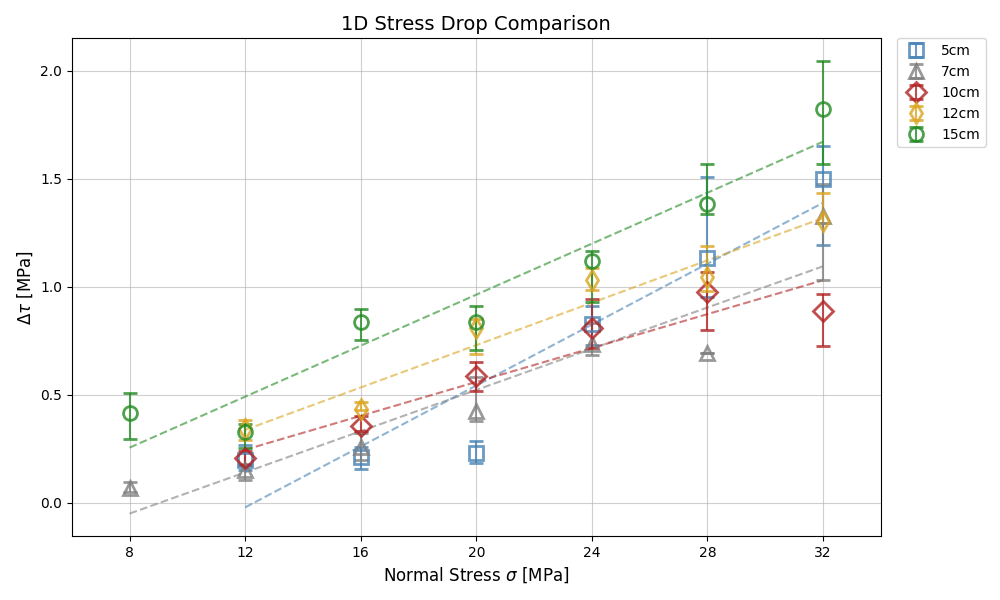

In [84]:
# ========= 5. 繪製 Tau Drop =========
plot_metric('delta_tau', r'1D Stress Drop Comparison', r'$\Delta\tau$ [MPa]')


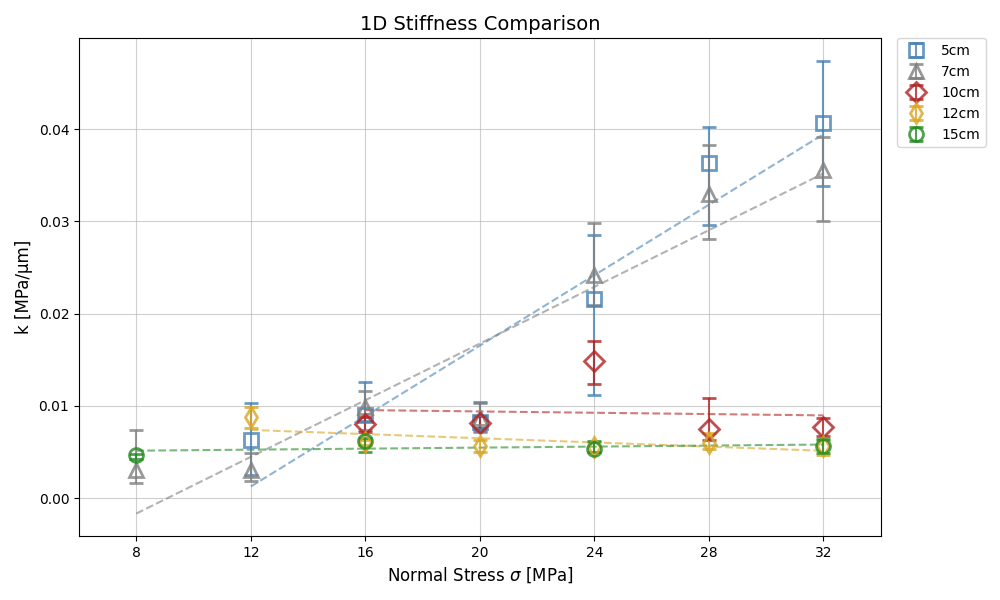

In [85]:
# ========= 6. 繪製 K Stiffness =========
plot_metric('k', '1D Stiffness Comparison', 'k [MPa/\u03bcm]')


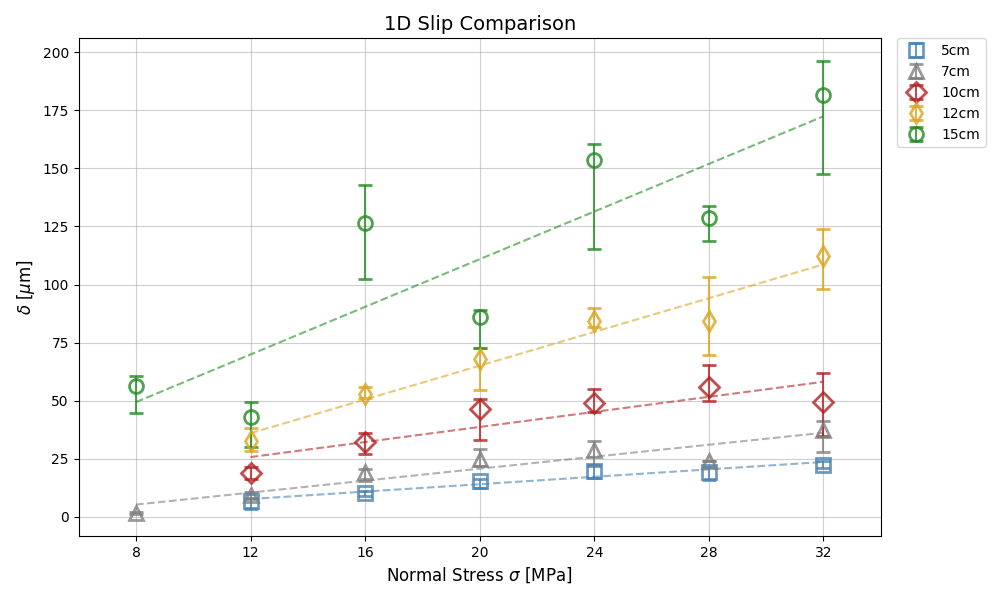

In [91]:
# ========= 7. 繪製 Delta (E2+E3+E4 平均) =========
plot_metric('delta_avg', r'1D Slip Comparison', r'$\delta$ [$\mu$m]', use_delta=True)


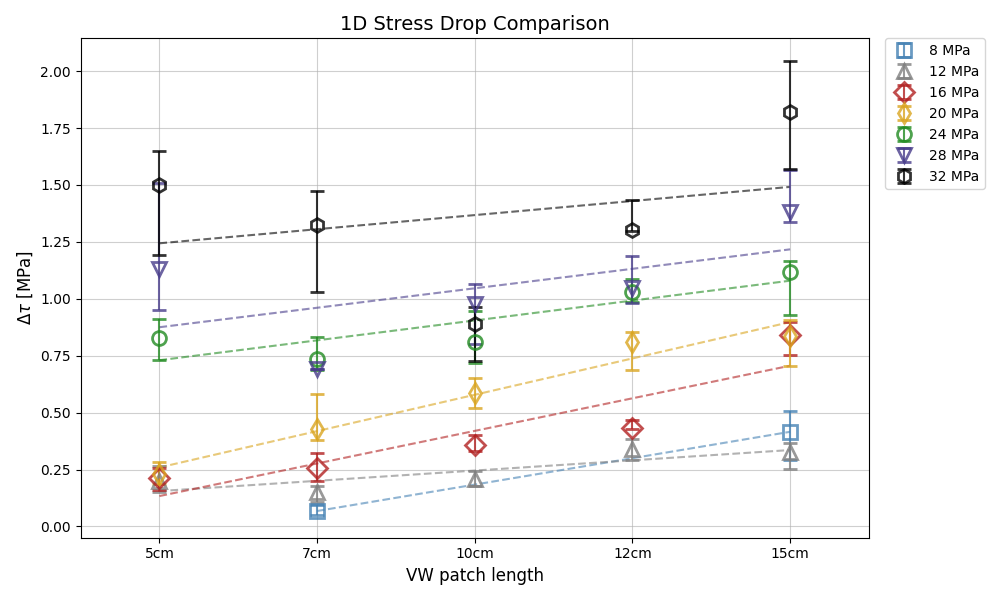

In [87]:
# ========= 8. 以群組為 X 軸：Tau Drop =========
plot_metric_by_group('delta_tau', r'1D Stress Drop Comparison', r'$\Delta\tau$ [MPa]')


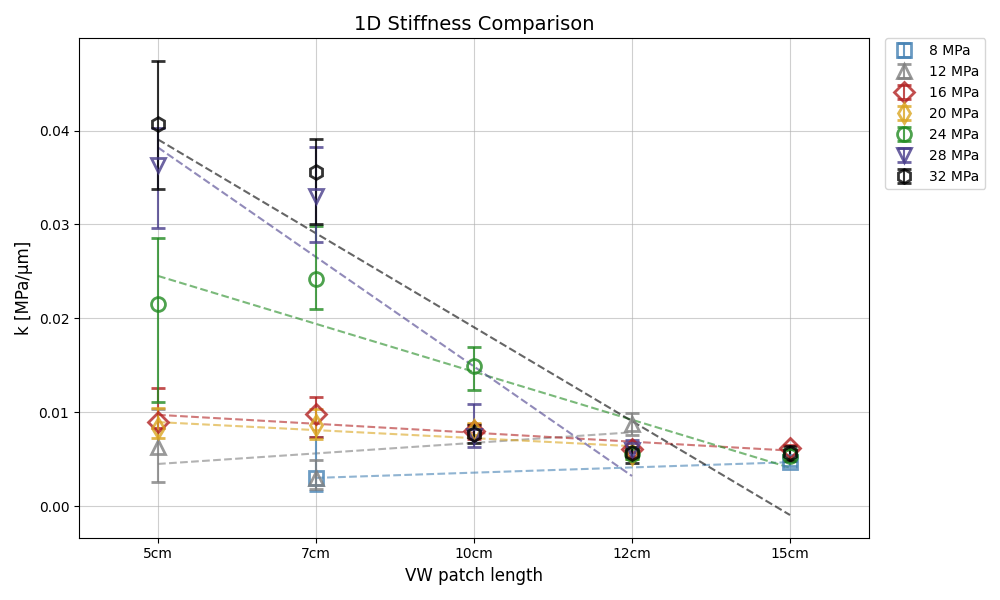

In [88]:
# ========= 9. 以群組為 X 軸：K Stiffness =========
plot_metric_by_group('k', '1D Stiffness Comparison', 'k [MPa/\u03bcm]')


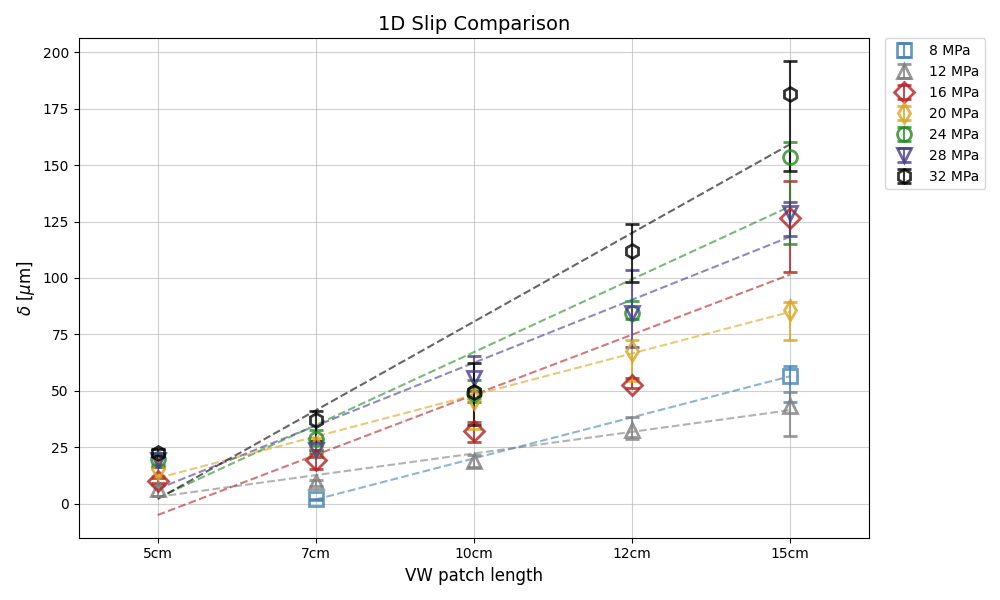

In [90]:
# ========= 10. 以群組為 X 軸：Delta =========
plot_metric_by_group('delta_avg', r'1D Slip Comparison', r'$\delta$ [$\mu$m]', use_delta=True)
